<a href="https://colab.research.google.com/github/srijan-raghavula/ser/blob/main/gnsc_hf_pipeline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 6G Semantic Communication — GNSC Algorithms
**Dataset:** COCO Captions 2017 · **LLM:** Phi-3-mini (HuggingFace `pipeline`) · **Algorithms:** ALG-1 through ALG-4

> Implements the GenAI-Native Semantic Communication (GNSC) problem.
> Pure functional style — all state flows through function arguments, no global mutation.

⚡ **GPU required.** Set `Runtime → Change runtime type → T4 GPU` before running.

| Cell | Purpose |
|------|---------|
| 1 | Install deps |
| 2 | Imports + device |
| 3 | Load Phi-3 via `hf_pipeline` |
| 4 | `phi3_infer()` helper |
| 5 | Download COCO Captions |
| 6 | Split dataset |
| 7 | Caption → semantic JSON (Phi-3) |
| 8 | Build all 4 splits (cached) |
| 9 | Channel model + config |
| 10 | GenAI model library |
| 11 | Tier-1 & Tier-2 SER metrics |
| 12 | Corruption + Module A repair |
| 13 | Module B surrogate predictor |
| 14 | Module C importance scoring |
| 15 | `SlotResult` dataclass |
| 16 | ALG-1: Baseline |
| 17 | ALG-2: Greedy SER-per-GB |
| 18 | ALG-3: Lyapunov |
| 19 | ALG-4: Q-Learning RL |
| 20 | Unified simulation runner |
| 21 | Run all splits |
| 22 | Statistics aggregation |
| 23 | Input vs Output JSON comparison |
| 24–30 | 7 plot figures |

### — Install dependencies

In [ ]:
!pip install --upgrade transformers accelerate sentencepiece
!pip install requests tqdm matplotlib seaborn scikit-learn
!pip install torch --index-url https://download.pytorch.org/whl/cu118

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 92.6 MB/s eta 0:00:00
  Attempting uninstall: transformers
    Found existing installation: transformers 5.0.0
    Uninstalling transformers-5.0.0:
      Successfully uninstalled transformers-5.0.0


Looking in indexes: https://download.pytorch.org/whl/cu118


### — Imports and device setup

In [1]:
import json
import math
import os
import random
import re
import zipfile
import urllib.request
from dataclasses import dataclass
from functools import partial
from statistics import mean, stdev
from typing import Dict, List, Optional, Tuple

import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from tqdm import tqdm

import torch
from transformers import pipeline as hf_pipeline

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = 0 if torch.cuda.is_available() else -1  # HF pipeline uses device index
DEVICE_NAME = torch.cuda.get_device_name(0) if DEVICE == 0 else "CPU"
print(f"[device] {'GPU' if DEVICE == 0 else 'CPU'}: {DEVICE_NAME}")

[device] GPU: Tesla T4


### — Load Phi-3 via HuggingFace pipeline

In [2]:
from transformers import AutoConfig, AutoModelForCausalLM, AutoTokenizer, pipeline
import torch

MODEL_ID = "microsoft/Phi-3-mini-4k-instruct"

# 1. Load config with trust_remote_code
config = AutoConfig.from_pretrained(MODEL_ID, trust_remote_code=True)

# 2. Fix missing RoPE scaling keys for Phi-3
if hasattr(config, "rope_scaling") and config.rope_scaling is not None:
    # Inject missing keys required by the modeling_phi3.py script
    config.rope_scaling["type"] = "longrope"
    if "short_factor" not in config.rope_scaling:
        config.rope_scaling["short_factor"] = [1.0] * (config.hidden_size // (config.num_attention_heads * 2))
    if "long_factor" not in config.rope_scaling:
        config.rope_scaling["long_factor"] = [1.0] * (config.hidden_size // (config.num_attention_heads * 2))
    if not hasattr(config, "original_max_position_embeddings"):
        config.original_max_position_embeddings = 4096

# 3. Load the model using the patched config
model = AutoModelForCausalLM.from_pretrained(
    MODEL_ID,
    config=config,
    torch_dtype=torch.float16,
    device_map="auto",
    trust_remote_code=False
)

tokenizer = AutoTokenizer.from_pretrained(MODEL_ID)

def load_phi3_pipeline(device: int = 0):
    print("[phi3] loading …")
    pipe = pipeline(
        "text-generation",
        model=model,
        tokenizer=tokenizer,
    )
    print(f"[phi3] ready on {'GPU' if device == 0 else 'CPU'}")
    return pipe

PHI3_PIPE = load_phi3_pipeline()

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/967 [00:00<?, ?B/s]

configuration_phi3.py: 0.00B [00:00, ?B/s]

A new version of the following files was downloaded from https://huggingface.co/microsoft/Phi-3-mini-4k-instruct:
- configuration_phi3.py
. Make sure to double-check they do not contain any added malicious code. To avoid downloading new versions of the code file, you can pin a revision.


model.safetensors.index.json: 0.00B [00:00, ?B/s]

...

tokenizer.json: 0.00B [00:00, ?B/s]

tokenizer.model:   0%|          | 0.00/500k [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/306 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/599 [00:00<?, ?B/s]

[phi3] loading …
[phi3] ready on GPU


### — Phi-3 inference helper (functional, stateless)

In [3]:
def phi3_infer(
    prompt: str,
    pipe,
    max_new_tokens: int = 256,
    temperature: float = 0.3,
) -> str:
    """
    Pure function: prompt str → response str.
    Uses HF pipeline chat-template message format.
    """
    messages = [{"role": "user", "content": prompt}]
    outputs = pipe(
        messages,
        max_new_tokens=max_new_tokens,
        max_length=None,           # <--- Suppresses the max_length collision warning
        temperature=temperature,
        do_sample=temperature > 0,
        return_full_text=False,
    )
    return outputs[0]["generated_text"].strip()

### — Download COCO Captions 2017 val annotations

In [4]:
"""
Why COCO Captions (not raw video/image datasets)?

  • Captions are natural-language scene descriptions — map directly to
    semantic triples {O, A, R, C} without needing a vision model.
  • 5 captions per image gives intra-scene diversity for corruption tests.
  • Structured JSON → easy batching, no pixel decoding.
  • ~40k images → four clean size splits (small/medium/big/all).
  • Matches the paper's guidance: skip full text-to-video, work on
    semantic correctness (SER) first.
  • Alternative considered: MS-COCO instances (has bboxes but no text);
    rejected because our S = {O,A,R,C} needs linguistic grounding.
"""
import os, urllib, zipfile

COCO_ZIP_URL  = "http://images.cocodataset.org/annotations/annotations_trainval2017.zip"
COCO_JSON_REL = "annotations/captions_val2017.json"


def download_coco_captions(dest_dir: str = "/content/coco") -> str:
    """Download & unzip COCO val captions. Returns path to JSON file."""
    os.makedirs(dest_dir, exist_ok=True)
    json_path = os.path.join(dest_dir, COCO_JSON_REL)
    if os.path.exists(json_path):
        print(f"[coco] already at {json_path}")
        return json_path
    zip_path = os.path.join(dest_dir, "annotations.zip")
    print("[coco] downloading (~252 MB) …")
    urllib.request.urlretrieve(COCO_ZIP_URL, zip_path)
    print("[coco] extracting …")
    with zipfile.ZipFile(zip_path) as zf:
        zf.extractall(dest_dir)
    print(f"[coco] done → {json_path}")
    return json_path


COCO_JSON_PATH = download_coco_captions()

[coco] downloading (~252 MB) …
[coco] extracting …
[coco] done → /content/coco/annotations/captions_val2017.json


### — Load and split COCO captions

In [5]:
def load_coco_captions(json_path: str) -> Dict[int, List[str]]:
    """Parse COCO annotations JSON → {image_id: [caption, …]}."""
    with open(json_path) as f:
        raw = json.load(f)
    grouped: Dict[int, List[str]] = {}
    for ann in raw["annotations"]:
        grouped.setdefault(ann["image_id"], []).append(ann["caption"])
    return grouped


def make_split(
    grouped: Dict[int, List[str]],
    n: int,
    seed: int = SEED,
) -> List[Dict]:
    """
    Sample n image records deterministically.
    Each record: {image_id: int, captions: List[str]}.
    """
    rng = random.Random(seed)
    ids = rng.sample(sorted(grouped.keys()), min(n, len(grouped)))
    return [{"image_id": i, "captions": grouped[i]} for i in ids]


ALL_GROUPED  = load_coco_captions(COCO_JSON_PATH)
SPLIT_SMALL  = make_split(ALL_GROUPED, 200)
SPLIT_MEDIUM = make_split(ALL_GROUPED, 1000)
SPLIT_BIG    = make_split(ALL_GROUPED, 5000)
SPLIT_ALL    = make_split(ALL_GROUPED, len(ALL_GROUPED))

print(f"[splits] small={len(SPLIT_SMALL)} | medium={len(SPLIT_MEDIUM)} | "
      f"big={len(SPLIT_BIG)} | all={len(SPLIT_ALL)}")

[splits] small=200 | medium=1000 | big=5000 | all=5000


### — Phi-3: caption → semantic JSON  {O, A, R, C}

In [6]:
EXTRACTION_PROMPT = (
    "You are a semantic parser. Given an image caption, output ONLY a valid "
    "JSON object with exactly these fields:\n"
    '  "objects"  : list of noun phrases (things, people, animals)\n'
    '  "actions"  : list of verb phrases (what is happening)\n'
    '  "relations": list of [subject, relation, object] triples\n'
    '  "context"  : one sentence summarising the overall scene\n\n'
    "Caption: {caption}\n\n"
    "Respond with ONLY the JSON. No explanation, no markdown fences."
)


def _parse_semantic_json(raw: str, fallback_caption: str) -> Dict:
    """Strip fences and parse JSON; return heuristic dict on failure."""
    clean = re.sub(r"```[a-z]*", "", raw).strip().strip("`")
    try:
        p = json.loads(clean)
        return {
            "objects":   list(p.get("objects",   [])),
            "actions":   list(p.get("actions",   [])),
            "relations": [list(r) for r in p.get("relations", [])],
            "context":   str(p.get("context",    fallback_caption)),
        }
    except json.JSONDecodeError:
        words = fallback_caption.lower().split()
        return {
            "objects":   words[:3],
            "actions":   words[3:5] if len(words) > 4 else ["unknown"],
            "relations": [[words[0], "near", words[-1]]] if len(words) > 1 else [],
            "context":   fallback_caption,
        }


def extract_semantics(caption: str, pipe) -> Dict:
    """Pure function: caption → semantic dict via Phi-3 pipeline."""
    prompt = EXTRACTION_PROMPT.format(caption=caption)
    raw    = phi3_infer(prompt, pipe, max_new_tokens=200, temperature=0.1)
    return _parse_semantic_json(raw, caption)


def enrich_record(record: Dict, pipe) -> Dict:
    """
    Input : {image_id, captions}
    Output: {image_id, captions, caption_used, semantic}
    Uses first caption as the ground-truth input to the LLM.
    """
    caption = record["captions"][0]
    return {**record, "caption_used": caption, "semantic": extract_semantics(caption, pipe)}


# demo on 3 records
_demos = [enrich_record(r, PHI3_PIPE) for r in SPLIT_SMALL[:3]]
for d in _demos:
    print(json.dumps({
        "image_id": d["image_id"],
        "caption":  d["caption_used"],
        "semantic": d["semantic"],
    }, indent=2))

Passing `generation_config` together with generation-related arguments=({'do_sample', 'max_new_tokens', 'temperature'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
Both `max_new_tokens` (=200) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=200) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=200) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_c

{
  "image_id": 107554,
  "caption": "a surf board leaning on a wheel barrel ",
  "semantic": {
    "objects": [
      "surf board",
      "wheel barrel"
    ],
    "actions": [],
    "relations": [
      [
        "surf board",
        "leaning on",
        "wheel barrel"
      ]
    ],
    "context": "A surfboard is leaning against a wheelbarrow."
  }
}
{
  "image_id": 21167,
  "caption": "The couple are dressed up and posing for photos.",
  "semantic": {
    "objects": [
      "the couple",
      "photos"
    ],
    "actions": [
      "are dressed up",
      "posing"
    ],
    "relations": [
      [
        "the couple",
        "are dressed up",
        "photos"
      ],
      [
        "the couple",
        "posing",
        "photos"
      ]
    ],
    "context": "A couple is dressed up and taking photos."
  }
}
{
  "image_id": 260657,
  "caption": "A worn and a new sign for the same Mexican food restaurant.",
  "semantic": {
    "objects": [
      "worn sign",
      "new sign",


### — Build enriched datasets for all splits (disk-cached)

In [8]:
def build_dataset(
    split: List[Dict],
    pipe,
    cache_path: Optional[str] = None,
) -> List[Dict]:
    """
    Map enrich_record over split.
    Saves to / loads from cache_path to avoid redundant LLM calls.
    """
    if cache_path and os.path.exists(cache_path):
        with open(cache_path) as f:
            data = json.load(f)
        print(f"[cache] loaded {len(data)} records from {cache_path}")
        return data

    results = [enrich_record(r, pipe) for r in tqdm(split, desc="extracting")]

    if cache_path:
        with open(cache_path, "w") as f:
            json.dump(results, f)
        print(f"[cache] saved to {cache_path}")
    return results


DS_SMALL  = build_dataset(SPLIT_SMALL,  PHI3_PIPE, "/content/ds_small.json")
DS_MEDIUM = build_dataset(SPLIT_MEDIUM, PHI3_PIPE, "/content/ds_medium.json")
# DS_BIG    = build_dataset(SPLIT_BIG,    PHI3_PIPE, "/content/ds_big.json")
# DS_ALL    = build_dataset(SPLIT_ALL,    PHI3_PIPE, "/content/ds_all.json")

print(f"[datasets] small={len(DS_SMALL)} | medium={len(DS_MEDIUM)}")

[cache] loaded 200 records from /content/ds_small.json



extracting:   0%|          | 0/1000 [00:00<?, ?it/s]Both `max_new_tokens` (=200) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)

extracting:   0%|          | 1/1000 [00:06<1:56:30,  7.00s/it]Both `max_new_tokens` (=200) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)

extracting:   0%|          | 2/1000 [00:11<1:29:32,  5.38s/it]Both `max_new_tokens` (=200) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)

extracting:   0%|          | 3/1000 [00:17<1:34:54,  5.71s/it]Both `max_n

[cache] saved to /content/ds_medium.json
[datasets] small=200 | medium=1000


In [9]:
from google.colab import drive
drive.mount('/content/drive')

ValueError: mount failed

### — System config and wireless channel model

In [15]:
@dataclass(frozen=True)
class SystemConfig:
    n_users:         int   = 4
    bmax_mhz:        float = 20.0
    smax_gb:         float = 8.0
    snr_min_db:      float = 5.0
    tau_max_ms:      float = 50.0
    tau_cloud_ms:    float = 80.0
    ser_max:         float = 0.30
    p_viol:          float = 0.10
    kappa:           float = 1.0


CFG = SystemConfig()


@dataclass(frozen=True)
class ChannelState:
    snr_db:        float
    bandwidth_mhz: float
    outage_prob:   float


def sample_channel(cfg: SystemConfig = CFG, rng: Optional[np.random.Generator] = None) -> ChannelState:
    """Rayleigh fading channel. |h|^2 ~ Exp(1). Returns ChannelState."""
    rng    = rng or np.random.default_rng()
    h2     = rng.exponential(1.0)
    snr_db = 10 * math.log10(max(h2, 1e-9)) + 20.0
    p_out  = math.exp(-10 ** (cfg.snr_min_db / 10))
    bw     = float(rng.uniform(1.0, cfg.bmax_mhz / cfg.n_users))
    return ChannelState(snr_db=snr_db, bandwidth_mhz=bw, outage_prob=p_out)


def tx_delay_ms(payload_tokens: int, ch: ChannelState, cfg: SystemConfig = CFG) -> float:
    """Shannon-capacity transmission delay in milliseconds."""
    snr_lin  = 10 ** (ch.snr_db / 10)
    rate_mbs = ch.bandwidth_mhz * math.log2(1 + snr_lin)
    eff_rate = (1 - ch.outage_prob) * rate_mbs
    return cfg.kappa * payload_tokens / max(eff_rate, 1e-3)

### — GenAI model library

In [16]:
@dataclass(frozen=True)
class GenAIModel:
    model_id:         int
    name:             str
    size_gb:          float
    quality:          float   # ∈ (0, 1]
    infer_latency_ms: float
    hallucination:    float   # ∈ [0, 1]


MODEL_LIBRARY: Tuple[GenAIModel, ...] = (
    GenAIModel(0, "phi3-mini",        2.0,  0.70, 12.0, 0.15),
    GenAIModel(1, "llama3-8b",        4.5,  0.82, 25.0, 0.10),
    GenAIModel(2, "mistral-7b",       3.8,  0.78, 20.0, 0.12),
    GenAIModel(3, "llama3-70b",      16.0,  0.94, 80.0, 0.04),
    GenAIModel(4, "phi3-medium",      8.0,  0.86, 35.0, 0.08),
    GenAIModel(5, "gemma-2b",         1.5,  0.62,  8.0, 0.20),
    GenAIModel(6, "qwen2-7b",         3.5,  0.80, 22.0, 0.11),
    GenAIModel(7, "stablelm-zephyr",  2.8,  0.68, 15.0, 0.17),
)
M_IDS = list(range(len(MODEL_LIBRARY)))


def gen_delay_ms(model: GenAIModel, cached: bool, cfg: SystemConfig = CFG) -> float:
    return model.infer_latency_ms + (0.0 if cached else cfg.tau_cloud_ms)

### — SER metrics (Tier-1 and Tier-2)

In [17]:
def jaccard_mismatch(a: List, b: List) -> float:
    """1 - |A∩B| / |A∪B|. Returns 0 if both empty."""
    sa, sb = set(map(str, a)), set(map(str, b))
    if not sa and not sb:
        return 0.0
    return 1.0 - len(sa & sb) / len(sa | sb)


def cosine_distance(a: str, b: str) -> float:
    """Character-level bag-of-words cosine distance. Lightweight proxy."""
    def bow(s: str) -> Dict[str, int]:
        return {c: s.count(c) for c in set(s)}
    va, vb = bow(a), bow(b)
    keys   = set(va) | set(vb)
    if not keys:
        return 0.0
    dot = sum(va.get(k, 0) * vb.get(k, 0) for k in keys)
    na  = math.sqrt(sum(v ** 2 for v in va.values()))
    nb  = math.sqrt(sum(v ** 2 for v in vb.values()))
    return 0.0 if na * nb == 0 else 1.0 - dot / (na * nb)


def tier1_ser(
    original: Dict,
    reconstructed: Dict,
    weights: Tuple[float, float, float, float] = (0.30, 0.20, 0.30, 0.20),
) -> float:
    """
    SER^(1) = α_o·Δ_jac(O,Ô) + α_a·Δ_jac(A,Â) + α_r·Δ_jac(R,R̂) + α_c·Δ_cos(c,ĉ)
    All weights sum to 1.
    """
    ao, aa, ar, ac = weights
    return (
        ao * jaccard_mismatch(original.get("objects",   []), reconstructed.get("objects",   []))
      + aa * jaccard_mismatch(original.get("actions",   []), reconstructed.get("actions",   []))
      + ar * jaccard_mismatch(original.get("relations", []), reconstructed.get("relations", []))
      + ac * cosine_distance( original.get("context",   ""), reconstructed.get("context",   ""))
    )


JUDGE_PROMPT = (
    "You are a semantic similarity judge. Compare the ORIGINAL and RECONSTRUCTED "
    "semantic scene descriptions.\n"
    "Score the semantic error from 0.0 (identical meaning) to 1.0 (completely different).\n"
    "Consider: object overlap, action similarity, relational accuracy, context coherence.\n"
    "Return ONLY a float between 0.0 and 1.0. No explanation.\n\n"
    "ORIGINAL:       {original}\n"
    "RECONSTRUCTED:  {reconstructed}"
)


def tier2_ser(original: Dict, reconstructed: Dict, pipe) -> float:
    """Module D — LLM judge for offline evaluation. Returns float in [0, 1]."""
    prompt = JUDGE_PROMPT.format(
        original=json.dumps(original),
        reconstructed=json.dumps(reconstructed),
    )
    raw = phi3_infer(prompt, pipe, max_new_tokens=10, temperature=0.0)
    m   = re.search(r"[0-9]+(?:\.[0-9]+)?", raw)
    return float(np.clip(float(m.group()), 0.0, 1.0)) if m else 0.5

### — Channel corruption and Module A semantic repair

In [18]:
def corrupt_semantics(
    sem: Dict,
    ch: ChannelState,
    rng: Optional[np.random.Generator] = None,
) -> Dict:
    """
    Simulate wireless corruption of a semantic packet:
      • token drops proportional to outage_prob + low-SNR penalty
      • random [UNK] substitutions at 15% rate
    Pure function — original dict is never modified.
    """
    rng    = rng or np.random.default_rng()
    p_drop = min(ch.outage_prob + max(0.0, (10.0 - ch.snr_db) / 30.0), 0.90)

    def drop_or_sub(items: List) -> List:
        out = []
        for item in items:
            if rng.random() < p_drop:
                continue
            out.append("[UNK]" if rng.random() < 0.15 else item)
        return out

    return {
        "objects":   drop_or_sub(sem.get("objects",   [])),
        "actions":   drop_or_sub(sem.get("actions",   [])),
        "relations": [r for r in sem.get("relations", []) if rng.random() > p_drop],
        "context":   sem.get("context", "") if rng.random() > p_drop * 0.5 else "",
    }


REPAIR_PROMPT = (
    "You are a semantic restoration system. A JSON semantic description was corrupted "
    "during wireless transmission.\n"
    "Restore it to a valid, coherent JSON with exactly these fields: "
    "objects (list), actions (list), relations (list of [s,r,o] triples), context (string).\n\n"
    "Corrupted input: {corrupted}\n\n"
    "Output ONLY the repaired JSON. No explanation."
)


def repair_semantics(corrupted: Dict, pipe) -> Dict:
    """Module A — Phi-3 online semantic repair. Falls back to corrupted on failure."""
    prompt = REPAIR_PROMPT.format(corrupted=json.dumps(corrupted))
    raw    = phi3_infer(prompt, pipe, max_new_tokens=200, temperature=0.1)
    clean  = re.sub(r"```[a-z]*", "", raw).strip().strip("`")
    try:
        p = json.loads(clean)
        return {
            "objects":   list(p.get("objects",   corrupted.get("objects",   []))),
            "actions":   list(p.get("actions",   corrupted.get("actions",   []))),
            "relations": [list(r) for r in p.get("relations", corrupted.get("relations", []))],
            "context":   str(p.get("context",    corrupted.get("context",   ""))),
        }
    except json.JSONDecodeError:
        return corrupted

### — Module B: surrogate SER/latency predictor

In [19]:
def semantic_features(sem: Dict, ch: ChannelState, mdl: GenAIModel) -> np.ndarray:
    """Extract a fixed-length feature vector for the surrogate predictor."""
    return np.array([
        len(sem.get("objects",   [])),
        len(sem.get("actions",   [])),
        len(sem.get("relations", [])),
        len(sem.get("context",   "").split()),
        ch.snr_db,
        ch.bandwidth_mhz,
        ch.outage_prob,
        mdl.quality,
        mdl.infer_latency_ms,
        mdl.hallucination,
        mdl.size_gb,
    ], dtype=np.float32)


def build_surrogate_data(
    dataset: List[Dict],
    n_samples: int = 800,
    seed: int = SEED,
) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
    """
    Generate (X, y_ser, y_lat) via analytic simulation.
    No LLM calls — uses Tier-1 SER directly for speed.
    """
    rng    = np.random.default_rng(seed)
    py_rng = random.Random(seed)
    X, y_ser, y_lat = [], [], []
    pool = [r for r in dataset if "semantic" in r]
    for _ in range(n_samples):
        rec = py_rng.choice(pool)
        mdl = py_rng.choice(MODEL_LIBRARY)
        ch  = sample_channel(rng=rng)
        sem = rec["semantic"]
        cor = corrupt_semantics(sem, ch, rng=rng)
        ser = tier1_ser(sem, cor)
        lat = tx_delay_ms(len(sem.get("context", "").split()), ch) + gen_delay_ms(mdl, cached=True)
        X.append(semantic_features(sem, ch, mdl))
        y_ser.append(ser)
        y_lat.append(lat)
    return np.array(X), np.array(y_ser), np.array(y_lat)


def train_surrogate_pipeline(X: np.ndarray, y: np.ndarray) -> Pipeline:
    pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("gbr",    GradientBoostingRegressor(n_estimators=100, max_depth=4, random_state=SEED)),
    ])
    pipe.fit(X, y)
    return pipe


def predict_ser_lat(
    sem: Dict,
    ch: ChannelState,
    mdl: GenAIModel,
    sur_ser: Pipeline,
    sur_lat: Pipeline,
) -> Tuple[float, float]:
    """Module B — fast surrogate prediction."""
    feats   = semantic_features(sem, ch, mdl).reshape(1, -1)
    ser_hat = float(np.clip(sur_ser.predict(feats)[0], 0.0, 1.0))
    lat_hat = float(np.clip(sur_lat.predict(feats)[0], 0.0, 500.0))
    return ser_hat, lat_hat


print("[surrogate] building training data from DS_MEDIUM …")
X_tr, y_ser_tr, y_lat_tr = build_surrogate_data(DS_MEDIUM, n_samples=800)
SURROGATE_SER = train_surrogate_pipeline(X_tr, y_ser_tr)
SURROGATE_LAT = train_surrogate_pipeline(X_tr, y_lat_tr)
print("[surrogate] trained SER and latency regressors")

[surrogate] building training data from DS_MEDIUM …
[surrogate] trained SER and latency regressors


### — Module C: Phi-3 importance scoring

In [20]:
IMPORTANCE_PROMPT = (
    "You are a semantic importance scorer for scene reconstruction.\n"
    "Given a semantic JSON, rate the importance of each field for reconstruction (0.0–1.0).\n"
    'Return ONLY JSON: {{"objects": float, "actions": float, "relations": float, "context": float}}\n\n'
    "Semantic: {semantic}"
)


def importance_scores(sem: Dict, pipe) -> Dict[str, float]:
    """Module C — LLM importance scoring. Returns {field: score ∈ [0,1]}."""
    prompt = IMPORTANCE_PROMPT.format(semantic=json.dumps(sem))
    raw    = phi3_infer(prompt, pipe, max_new_tokens=60, temperature=0.1)
    clean  = re.sub(r"```[a-z]*", "", raw).strip().strip("`")
    try:
        scores = json.loads(clean)
        return {k: float(np.clip(scores.get(k, 0.5), 0.0, 1.0))
                for k in ("objects", "actions", "relations", "context")}
    except Exception:
        return {"objects": 0.5, "actions": 0.4, "relations": 0.6, "context": 0.3}

### — SlotResult dataclass

In [21]:
@dataclass
class SlotResult:
    record_id:       int
    algorithm:       str
    model_selected:  int
    cached:          bool
    channel_snr_db:  float
    bandwidth_mhz:   float
    payload_tokens:  int
    tx_delay_ms:     float
    gen_delay_ms:    float
    total_latency:   float
    tier1_ser:       float
    tier2_ser:       Optional[float]
    repaired:        bool
    cache_state:     List[int]
    input_semantic:  Dict
    output_semantic: Dict

### — ALG-1: Baseline (LRU cache + equal BW + random model)

In [22]:
def greedy_cache_by(score_fn, cfg: SystemConfig = CFG) -> List[int]:
    """Generic greedy knapsack: fill cache by descending score_fn(model)."""
    ranked = sorted(MODEL_LIBRARY, key=score_fn, reverse=True)
    cache, used = [], 0.0
    for m in ranked:
        if used + m.size_gb <= cfg.smax_gb:
            cache.append(m.model_id)
            used += m.size_gb
    return cache


def alg1_init_cache(cfg: SystemConfig = CFG) -> List[int]:
    """LRU-popularity: sort by quality/size ratio."""
    return greedy_cache_by(lambda m: m.quality / m.size_gb, cfg)


def alg1_slot(
    record: Dict,
    cache: List[int],
    rng: np.random.Generator,
    cfg: SystemConfig = CFG,
) -> Tuple[SlotResult, List[int]]:
    """
    ALG-1: equal bandwidth, random cached model, no repair.
    Cache is never updated inside this function (stateless w.r.t. cache).
    """
    ch  = sample_channel(cfg, rng)
    bw  = cfg.bmax_mhz / cfg.n_users
    ch_ = ChannelState(ch.snr_db, bw, ch.outage_prob)
    sem = record["semantic"]
    tok = len(sem.get("context", "").split()) + len(sem.get("objects", [])) * 2

    avail = cache if cache else M_IDS
    mid   = int(rng.choice(avail))
    mdl   = MODEL_LIBRARY[mid]

    cor   = corrupt_semantics(sem, ch_, rng)
    ser   = tier1_ser(sem, cor)
    tx_d  = tx_delay_ms(tok, ch_)
    gen_d = gen_delay_ms(mdl, mid in cache, cfg)

    return SlotResult(
        record_id=record["image_id"], algorithm="ALG-1",
        model_selected=mid, cached=(mid in cache),
        channel_snr_db=ch.snr_db, bandwidth_mhz=bw,
        payload_tokens=tok, tx_delay_ms=tx_d, gen_delay_ms=gen_d,
        total_latency=tx_d + gen_d, tier1_ser=ser, tier2_ser=None,
        repaired=False, cache_state=list(cache),
        input_semantic=sem, output_semantic=cor,
    ), cache

### — ALG-2: Greedy SER-per-GB + semantic BW + self-consistency

In [23]:
def semantic_bandwidth(
    importance: Dict[str, float],
    all_scores: List[float],
    bmax: float,
) -> float:
    """Allocate BW proportional to total importance score vs pool."""
    my_score  = sum(importance.values())
    total     = sum(all_scores) or 1.0
    return bmax * my_score / total


def self_consistency_model(
    sem: Dict,
    ch: ChannelState,
    cache: List[int],
    sur_ser: Pipeline,
    sur_lat: Pipeline,
    k: int = 3,
    lambda_lat: float = 0.4,
    cfg: SystemConfig = CFG,
    rng: Optional[np.random.Generator] = None,
) -> int:
    """Sample K candidate models, return argmin(SER_hat + λ·lat_hat/τ_max)."""
    rng        = rng or np.random.default_rng()
    candidates = list(rng.choice(M_IDS, size=min(k, len(M_IDS)), replace=False))
    best_cost, best_mid = float("inf"), candidates[0]
    for mid in candidates:
        s_hat, l_hat = predict_ser_lat(sem, ch, MODEL_LIBRARY[mid], sur_ser, sur_lat)
        cost = s_hat + lambda_lat * l_hat / cfg.tau_max_ms
        if cost < best_cost:
            best_cost, best_mid = cost, mid
    return best_mid


def alg2_cache_update(
    dataset: List[Dict],
    sur_ser: Pipeline,
    sur_lat: Pipeline,
    cfg: SystemConfig = CFG,
) -> List[int]:
    """Greedy knapsack sorted by SER-reduction-per-GB."""
    ch_avg  = ChannelState(snr_db=15.0, bandwidth_mhz=5.0, outage_prob=0.05)
    sem_avg = dataset[0]["semantic"] if dataset else {}

    def efficiency(mdl: GenAIModel) -> float:
        s_hat, _ = predict_ser_lat(sem_avg, ch_avg, mdl, sur_ser, sur_lat)
        return (1.0 - s_hat) / mdl.size_gb

    return greedy_cache_by(efficiency, cfg)


def alg2_slot(
    record: Dict,
    cache: List[int],
    pool_scores: List[float],
    pipe,
    sur_ser: Pipeline,
    sur_lat: Pipeline,
    gamma_th_db: float = 8.0,
    rng: Optional[np.random.Generator] = None,
    cfg: SystemConfig = CFG,
) -> Tuple[SlotResult, List[int]]:
    """
    ALG-2: Module C → semantic BW; Module B → self-consistency model;
           Module A → conditional repair when SNR < threshold.
    """
    rng = rng or np.random.default_rng()
    ch  = sample_channel(cfg, rng)
    imp = importance_scores(record["semantic"], pipe)
    bw  = semantic_bandwidth(imp, pool_scores, cfg.bmax_mhz)
    ch_ = ChannelState(ch.snr_db, bw, ch.outage_prob)
    sem = record["semantic"]
    tok = int(sum(imp.values()) * 30) + 20

    mid   = self_consistency_model(sem, ch_, cache, sur_ser, sur_lat, rng=rng, cfg=cfg)
    mdl   = MODEL_LIBRARY[mid]
    cor   = corrupt_semantics(sem, ch_, rng)
    out   = cor
    fixed = False
    if ch.snr_db < gamma_th_db:
        out   = repair_semantics(cor, pipe)
        fixed = True

    ser   = tier1_ser(sem, out)
    tx_d  = tx_delay_ms(tok, ch_)
    gen_d = gen_delay_ms(mdl, mid in cache, cfg)

    return SlotResult(
        record_id=record["image_id"], algorithm="ALG-2",
        model_selected=mid, cached=(mid in cache),
        channel_snr_db=ch.snr_db, bandwidth_mhz=bw,
        payload_tokens=tok, tx_delay_ms=tx_d, gen_delay_ms=gen_d,
        total_latency=tx_d + gen_d, tier1_ser=ser, tier2_ser=None,
        repaired=fixed, cache_state=list(cache),
        input_semantic=sem, output_semantic=out,
    ), cache

### — ALG-3: Lyapunov Drift-Plus-Penalty

In [24]:
@dataclass
class LyapunovState:
    Q: np.ndarray   # latency virtual queues  shape [n_users]
    Z: np.ndarray   # SER violation queues    shape [n_users]


def init_lyapunov(n_users: int) -> LyapunovState:
    return LyapunovState(Q=np.zeros(n_users), Z=np.zeros(n_users))


def update_queues(
    state: LyapunovState,
    user_idx: int,
    latency: float,
    ser: float,
    cfg: SystemConfig = CFG,
) -> LyapunovState:
    """Pure update: returns new LyapunovState without mutating old one."""
    Q_new = state.Q.copy()
    Z_new = state.Z.copy()
    Q_new[user_idx] = max(0.0, state.Q[user_idx] + latency - cfg.tau_max_ms)
    Z_new[user_idx] = max(0.0, state.Z[user_idx] + float(ser > cfg.ser_max) - cfg.p_viol)
    return LyapunovState(Q=Q_new, Z=Z_new)


def lyapunov_cost(
    sem: Dict,
    ch: ChannelState,
    mdl: GenAIModel,
    bw: float,
    q_u: float,
    z_u: float,
    w_u: float,
    V: float,
    sur_ser: Pipeline,
    sur_lat: Pipeline,
    cfg: SystemConfig = CFG,
) -> Tuple[float, float, float]:
    """
    Ψ_u = V·w_u·SER_hat + Q_u·τ_hat + Z_u·I[SER_hat > SER_max]
    Returns (cost, ser_hat, lat_hat).
    """
    ch_bw   = ChannelState(ch.snr_db, bw, ch.outage_prob)
    s_hat, _ = predict_ser_lat(sem, ch_bw, mdl, sur_ser, sur_lat)
    tok      = len(sem.get("context", "").split()) + len(sem.get("objects", [])) * 2
    l_hat    = tx_delay_ms(tok, ch_bw) + gen_delay_ms(mdl, cached=True, cfg=cfg)
    viol     = float(s_hat > cfg.ser_max)
    cost     = V * w_u * s_hat + q_u * l_hat + z_u * viol
    return cost, s_hat, l_hat


def alg3_cache_update(
    dataset: List[Dict],
    state: LyapunovState,
    sur_lat: Pipeline,
    cfg: SystemConfig = CFG,
) -> List[int]:
    """Cache update: weighted knapsack minimising Q-weighted expected latency."""
    ch_avg  = ChannelState(snr_db=15.0, bandwidth_mhz=5.0, outage_prob=0.05)
    sem_avg = dataset[0]["semantic"] if dataset else {}
    q_total = float(state.Q.sum()) or 1.0

    def score(mdl: GenAIModel) -> float:
        _, l_hat = predict_ser_lat(sem_avg, ch_avg, mdl, SURROGATE_SER, sur_lat)
        return q_total / (mdl.size_gb * max(l_hat, 1.0))

    return greedy_cache_by(score, cfg)


def alg3_slot(
    record: Dict,
    cache: List[int],
    state: LyapunovState,
    user_idx: int,
    pipe,
    sur_ser: Pipeline,
    sur_lat: Pipeline,
    V: float = 50.0,
    w_u: float = 1.0,
    bw_levels: int = 5,
    rng: Optional[np.random.Generator] = None,
    cfg: SystemConfig = CFG,
) -> Tuple[SlotResult, LyapunovState]:
    """
    ALG-3: grid search over (BW × model) to minimise Lyapunov cost.
    Always applies Module A repair. Updates virtual queues after execution.
    """
    rng    = rng or np.random.default_rng()
    ch     = sample_channel(cfg, rng)
    sem    = record["semantic"]
    q_u    = state.Q[user_idx]
    z_u    = state.Z[user_idx]
    bw_grid = np.linspace(cfg.bmax_mhz / (cfg.n_users * 2), cfg.bmax_mhz / cfg.n_users, bw_levels)

    best_cost, best_mid, best_bw = float("inf"), M_IDS[0], bw_grid[0]
    for bw in bw_grid:
        for mid in M_IDS:
            cost, _, _ = lyapunov_cost(sem, ch, MODEL_LIBRARY[mid], bw, q_u, z_u, w_u, V, sur_ser, sur_lat, cfg)
            if cost < best_cost:
                best_cost, best_mid, best_bw = cost, mid, bw

    mdl   = MODEL_LIBRARY[best_mid]
    ch_   = ChannelState(ch.snr_db, best_bw, ch.outage_prob)
    tok   = len(sem.get("context", "").split()) + len(sem.get("objects", [])) * 2
    cor   = corrupt_semantics(sem, ch_, rng)
    rep   = repair_semantics(cor, pipe)          # Module A always on
    ser   = tier1_ser(sem, rep)
    tx_d  = tx_delay_ms(tok, ch_)
    gen_d = gen_delay_ms(mdl, best_mid in cache, cfg)
    lat   = tx_d + gen_d

    new_state = update_queues(state, user_idx, lat, ser, cfg)

    return SlotResult(
        record_id=record["image_id"], algorithm="ALG-3",
        model_selected=best_mid, cached=(best_mid in cache),
        channel_snr_db=ch.snr_db, bandwidth_mhz=best_bw,
        payload_tokens=tok, tx_delay_ms=tx_d, gen_delay_ms=gen_d,
        total_latency=lat, tier1_ser=ser, tier2_ser=None,
        repaired=True, cache_state=list(cache),
        input_semantic=sem, output_semantic=rep,
    ), new_state

### — ALG-4: Q-Learning RL baseline

In [25]:
N_SNR_BINS, N_COMP_BINS, N_CACHE_BINS = 5, 4, 8
N_ACTIONS = len(M_IDS)


def discretise(ch: ChannelState, sem: Dict, cache: List[int]) -> Tuple[int, int, int]:
    snr_bin  = int(np.clip((ch.snr_db + 5) / 6, 0, N_SNR_BINS - 1))
    comp     = len(sem.get("objects", [])) + len(sem.get("actions", [])) + len(sem.get("relations", []))
    comp_bin = int(np.clip(comp / 5, 0, N_COMP_BINS - 1))
    cache_fp = hash(tuple(sorted(cache))) % N_CACHE_BINS
    return snr_bin, comp_bin, cache_fp


def eps_greedy(q_row: np.ndarray, eps: float, rng: np.random.Generator) -> int:
    return int(rng.integers(0, len(q_row))) if rng.random() < eps else int(np.argmax(q_row))


def q_update(
    Q: np.ndarray,
    s: Tuple, a: int, r: float, s_next: Tuple,
    alpha: float = 0.1, gamma: float = 0.95,
) -> np.ndarray:
    Q_new       = Q.copy()
    Q_new[s][a] += alpha * (r + gamma * np.max(Q[s_next]) - Q[s][a])
    return Q_new


def rl_reward(ser: float, lat: float, w: float = 1.0, lam: float = 0.5, cfg: SystemConfig = CFG) -> float:
    return -w * ser - lam * max(0.0, lat - cfg.tau_max_ms)


def alg4_slot(
    record: Dict,
    cache: List[int],
    Q: np.ndarray,
    eps: float,
    rng: np.random.Generator,
    cfg: SystemConfig = CFG,
) -> Tuple[SlotResult, np.ndarray, float]:
    """
    ALG-4 Q-learning. Returns (SlotResult, updated_Q, new_epsilon).
    """
    ch    = sample_channel(cfg, rng)
    bw    = cfg.bmax_mhz / cfg.n_users
    ch_   = ChannelState(ch.snr_db, bw, ch.outage_prob)
    sem   = record["semantic"]
    state = discretise(ch, sem, cache)

    action = eps_greedy(Q[state], eps, rng)
    mid    = M_IDS[action]
    mdl    = MODEL_LIBRARY[mid]
    tok    = len(sem.get("context", "").split()) + len(sem.get("objects", [])) * 2
    cor    = corrupt_semantics(sem, ch_, rng)
    ser    = tier1_ser(sem, cor)
    tx_d   = tx_delay_ms(tok, ch_)
    gen_d  = gen_delay_ms(mdl, mid in cache, cfg)
    lat    = tx_d + gen_d

    reward  = rl_reward(ser, lat)
    s_next  = discretise(ch, sem, cache)
    Q_new   = q_update(Q, state, action, reward, s_next)
    eps_new = max(0.05, eps * 0.995)

    return SlotResult(
        record_id=record["image_id"], algorithm="ALG-4",
        model_selected=mid, cached=(mid in cache),
        channel_snr_db=ch.snr_db, bandwidth_mhz=bw,
        payload_tokens=tok, tx_delay_ms=tx_d, gen_delay_ms=gen_d,
        total_latency=lat, tier1_ser=ser, tier2_ser=None,
        repaired=False, cache_state=list(cache),
        input_semantic=sem, output_semantic=cor,
    ), Q_new, eps_new

### — Unified simulation runner (all 4 algorithms)

In [26]:
def run_simulation(
    dataset: List[Dict],
    pipe,
    sur_ser: Pipeline,
    sur_lat: Pipeline,
    cfg: SystemConfig = CFG,
    tc_epoch: int = 20,
    tier2_every: int = 50,
    seed: int = SEED,
) -> Dict[str, List[SlotResult]]:
    """
    Runs all 4 algorithms on every record in dataset.
    Each algorithm maintains its own independent state.
    Returns {alg_name: [SlotResult, ...]}.
    """
    rng = np.random.default_rng(seed)

    # --- per-algorithm initial state ---
    cache1    = alg1_init_cache(cfg)
    cache2    = alg2_cache_update(dataset, sur_ser, sur_lat, cfg)
    cache3    = alg1_init_cache(cfg)
    cache4    = alg1_init_cache(cfg)
    lya       = init_lyapunov(cfg.n_users)
    Q_table   = np.zeros((N_SNR_BINS, N_COMP_BINS, N_CACHE_BINS, N_ACTIONS))
    epsilon   = 1.0

    results: Dict[str, List[SlotResult]] = {k: [] for k in ("ALG-1", "ALG-2", "ALG-3", "ALG-4")}

    # pre-compute importance pool scores for ALG-2 bandwidth normalisation
    print("[sim] pre-computing importance scores for ALG-2 …")
    imp_sample = [
        sum(importance_scores(r["semantic"], pipe).values())
        for r in tqdm(dataset[:min(50, len(dataset))], desc="importance")
    ]
    pool_scores = [imp_sample[i % len(imp_sample)] for i in range(len(dataset))]

    print(f"[sim] running {len(dataset)} slots …")
    for t, rec in enumerate(tqdm(dataset, desc="slots")):

        # epoch-level cache updates
        if t % tc_epoch == 0 and t > 0:
            cache2 = alg2_cache_update(dataset[:t], sur_ser, sur_lat, cfg)
            cache3 = alg3_cache_update(dataset[:t], lya, sur_lat, cfg)

        user_idx = t % cfg.n_users

        # ALG-1
        r1, cache1 = alg1_slot(rec, cache1, rng, cfg)

        # ALG-2
        r2, cache2 = alg2_slot(rec, cache2, pool_scores, pipe, sur_ser, sur_lat, rng=rng, cfg=cfg)

        # ALG-3
        r3, lya    = alg3_slot(rec, cache3, lya, user_idx, pipe, sur_ser, sur_lat, rng=rng, cfg=cfg)

        # ALG-4
        r4, Q_table, epsilon = alg4_slot(rec, cache4, Q_table, epsilon, rng, cfg)

        results["ALG-1"].append(r1)
        results["ALG-2"].append(r2)
        results["ALG-3"].append(r3)
        results["ALG-4"].append(r4)

        # Tier-2 SER spot-check (Module D — expensive, sparse)
        if t % tier2_every == 0:
            for key, slot in (("ALG-1", r1), ("ALG-3", r3)):
                t2 = tier2_ser(slot.input_semantic, slot.output_semantic, pipe)
                results[key][-1].tier2_ser = t2

    print("[sim] done.")
    return results

### — Run all splits

In [27]:
print("=" * 60 + "\n[run] SMALL split")
RES_SMALL  = run_simulation(DS_SMALL,  PHI3_PIPE, SURROGATE_SER, SURROGATE_LAT, tc_epoch=10,  tier2_every=20)

print("[run] MEDIUM split")
RES_MEDIUM = run_simulation(DS_MEDIUM, PHI3_PIPE, SURROGATE_SER, SURROGATE_LAT, tc_epoch=20,  tier2_every=50)

# print("[run] BIG split")
# RES_BIG    = run_simulation(DS_BIG,    PHI3_PIPE, SURROGATE_SER, SURROGATE_LAT, tc_epoch=50,  tier2_every=100)

# print("[run] ALL split")
# RES_ALL    = run_simulation(DS_ALL,    PHI3_PIPE, SURROGATE_SER, SURROGATE_LAT, tc_epoch=100, tier2_every=200)

[run] SMALL split
[sim] pre-computing importance scores for ALG-2 …


importance: 100%|██████████| 50/50 [02:10<00:00,  2.60s/it]


[sim] running 200 slots …


slots:   0%|          | 0/200 [00:00<?, ?it/s]Both `max_new_tokens` (=60) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=200) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
The following generation flags are not valid and may be ignored: ['temperature']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
Both `max_new_tokens` (=10) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=10) and `max_length`(=20) seem to have been set. `m

[sim] done.
[run] MEDIUM split
[sim] pre-computing importance scores for ALG-2 …


importance: 100%|██████████| 50/50 [01:59<00:00,  2.39s/it]


[sim] running 1000 slots …


slots:   0%|          | 0/1000 [00:00<?, ?it/s]Both `max_new_tokens` (=60) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=200) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=10) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=10) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformer

[sim] done.


### — Statistics aggregation

In [30]:
@dataclass
class AlgStats:
    algorithm:       str
    split:           str
    n_slots:         int
    mean_ser:        float
    std_ser:         float
    mean_latency:    float
    std_latency:     float
    p_lat_violation: float
    p_ser_violation: float
    cache_hit_rate:  float
    repair_rate:     float
    mean_bw:         float
    tier2_mean:      Optional[float]


def compute_stats(
    results: Dict[str, List["SlotResult"]],
    split_name: str,
    cfg: Optional["SystemConfig"] = None,
) -> List[AlgStats]:
    # Use global CFG if not provided
    _cfg = cfg if cfg is not None else CFG
    stats = []
    for alg, slots in results.items():
        sers = [s.tier1_ser     for s in slots]
        lats = [s.total_latency for s in slots]
        t2s  = [s.tier2_ser     for s in slots if s.tier2_ser is not None]
        stats.append(AlgStats(
            algorithm=alg, split=split_name, n_slots=len(slots),
            mean_ser=mean(sers),   std_ser=stdev(sers) if len(sers) > 1 else 0.0,
            mean_latency=mean(lats), std_latency=stdev(lats) if len(lats) > 1 else 0.0,
            p_lat_violation=mean([float(l > _cfg.tau_max_ms) for l in lats]),
            p_ser_violation=mean([float(s > _cfg.ser_max)    for s in sers]),
            cache_hit_rate=mean([float(s.cached)   for s in slots]),
            repair_rate=mean([float(s.repaired)    for s in slots]),
            mean_bw=mean([s.bandwidth_mhz   for s in slots]),
            tier2_mean=mean(t2s) if t2s else None,
        ))
    return stats

ALL_STATS = {
    "small":  compute_stats(RES_SMALL,  "small"),
    "medium": compute_stats(RES_MEDIUM, "medium"),
}

# pretty-print table
hdr = f"{'Split':<8} {'Alg':<8} {'SER↓':<10} {'Lat(ms)↓':<12} {'P(lat>τ)↓':<12} {'P(SER>max)↓':<14} {'CacheHit↑':<10}"
print('\n' + hdr)
print('-' * len(hdr))
for sp in ("small", "medium"):
    if sp in ALL_STATS:
        for s in ALL_STATS[sp]:
            print(f"{s.split:<8} {s.algorithm:<8} {s.mean_ser:<10.4f} {s.mean_latency:<12.2f} "
                  f"{s.p_lat_violation:<12.3f} {s.p_ser_violation:<14.3f} {s.cache_hit_rate:<10.3f}")
        print()


Split    Alg      SER↓       Lat(ms)↓     P(lat>τ)↓    P(SER>max)↓    CacheHit↑ 
--------------------------------------------------------------------------------
small    ALG-1    0.1271     12.60        0.000        0.115          1.000     
small    ALG-2    0.1199     257.95       1.000        0.120          0.820     
small    ALG-3    0.1716     14.85        0.035        0.225          0.965     
small    ALG-4    0.1040     59.00        0.440        0.040          0.560     

medium   ALG-1    0.1277     12.45        0.000        0.092          1.000     
medium   ALG-2    0.1239     1526.48      1.000        0.086          0.811     
medium   ALG-3    0.1682     14.96        0.037        0.224          0.963     
medium   ALG-4    0.1216     29.14        0.158        0.097          0.843     



rng_compare = random.Random(SEED)
# Using RES_MEDIUM since RES_ALL was skipped
compare_slots = rng_compare.sample(RES_MEDIUM["ALG-3"], 10)

print(f"{'ID':<8} {'Tier-1 SER':>12} {'Tier-2 SER':>12}  INPUT objects → OUTPUT objects")
print("-" * 80)
for sr in compare_slots:
    t2 = sr.tier2_ser if sr.tier2_ser is not None else \
         tier2_ser(sr.input_semantic, sr.output_semantic, PHI3_PIPE)
    inp = sr.input_semantic.get("objects",  [])[:3]
    out = sr.output_semantic.get("objects", [])[:3]
    print(f"{sr.record_id:<8} {sr.tier1_ser:>12.4f} {t2:>12.4f}  {inp} → {out}")

In [33]:
rng_compare = random.Random(SEED)
# Updated to RES_MEDIUM to prevent NameError
compare_slots = rng_compare.sample(RES_MEDIUM["ALG-3"], 10)

print(f"{'ID':<8} {'Tier-1 SER':>12} {'Tier-2 SER':>12}  INPUT objects → OUTPUT objects")
print("-" * 80)
for sr in compare_slots:
    t2 = sr.tier2_ser if sr.tier2_ser is not None else \
         tier2_ser(sr.input_semantic, sr.output_semantic, PHI3_PIPE)
    inp = sr.input_semantic.get("objects",  [])[:3]
    out = sr.output_semantic.get("objects", [])[:3]
    print(f"{sr.record_id:<8} {sr.tier1_ser:>12.4f} {t2:>12.4f}  {inp} → {out}")

Both `max_new_tokens` (=10) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


ID         Tier-1 SER   Tier-2 SER  INPUT objects → OUTPUT objects
--------------------------------------------------------------------------------


Both `max_new_tokens` (=10) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


565153         0.1333       0.1000  ['road sign', 'road', 'forest'] → ['road sign', 'road', 'forest']


Both `max_new_tokens` (=10) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


...

233033         0.5000       0.1000  ['outdoor', 'patio', 'chairs'] → ['outdoor', 'patio', 'chairs']


Both `max_new_tokens` (=10) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


284106         0.4000       0.2000  ['plate of chicken', 'vegetables', 'bowl of rice'] → ['plate of chicken', 'vegetables', 'bowl of rice']


Both `max_new_tokens` (=10) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


115885         0.0000       0.0000  ['brown cat', 'white cat', 'black cat'] → ['brown cat', 'white cat', 'black cat']
556765         0.2833       0.1000  ['baby elephant', 'river'] → ['baby elephant', 'river']


### — Plots: Global Benchmark Comparison (Fig 0)
This figure compares the mean SER, latency, cache hits, and violation rates across all algorithms for the completed data splits.

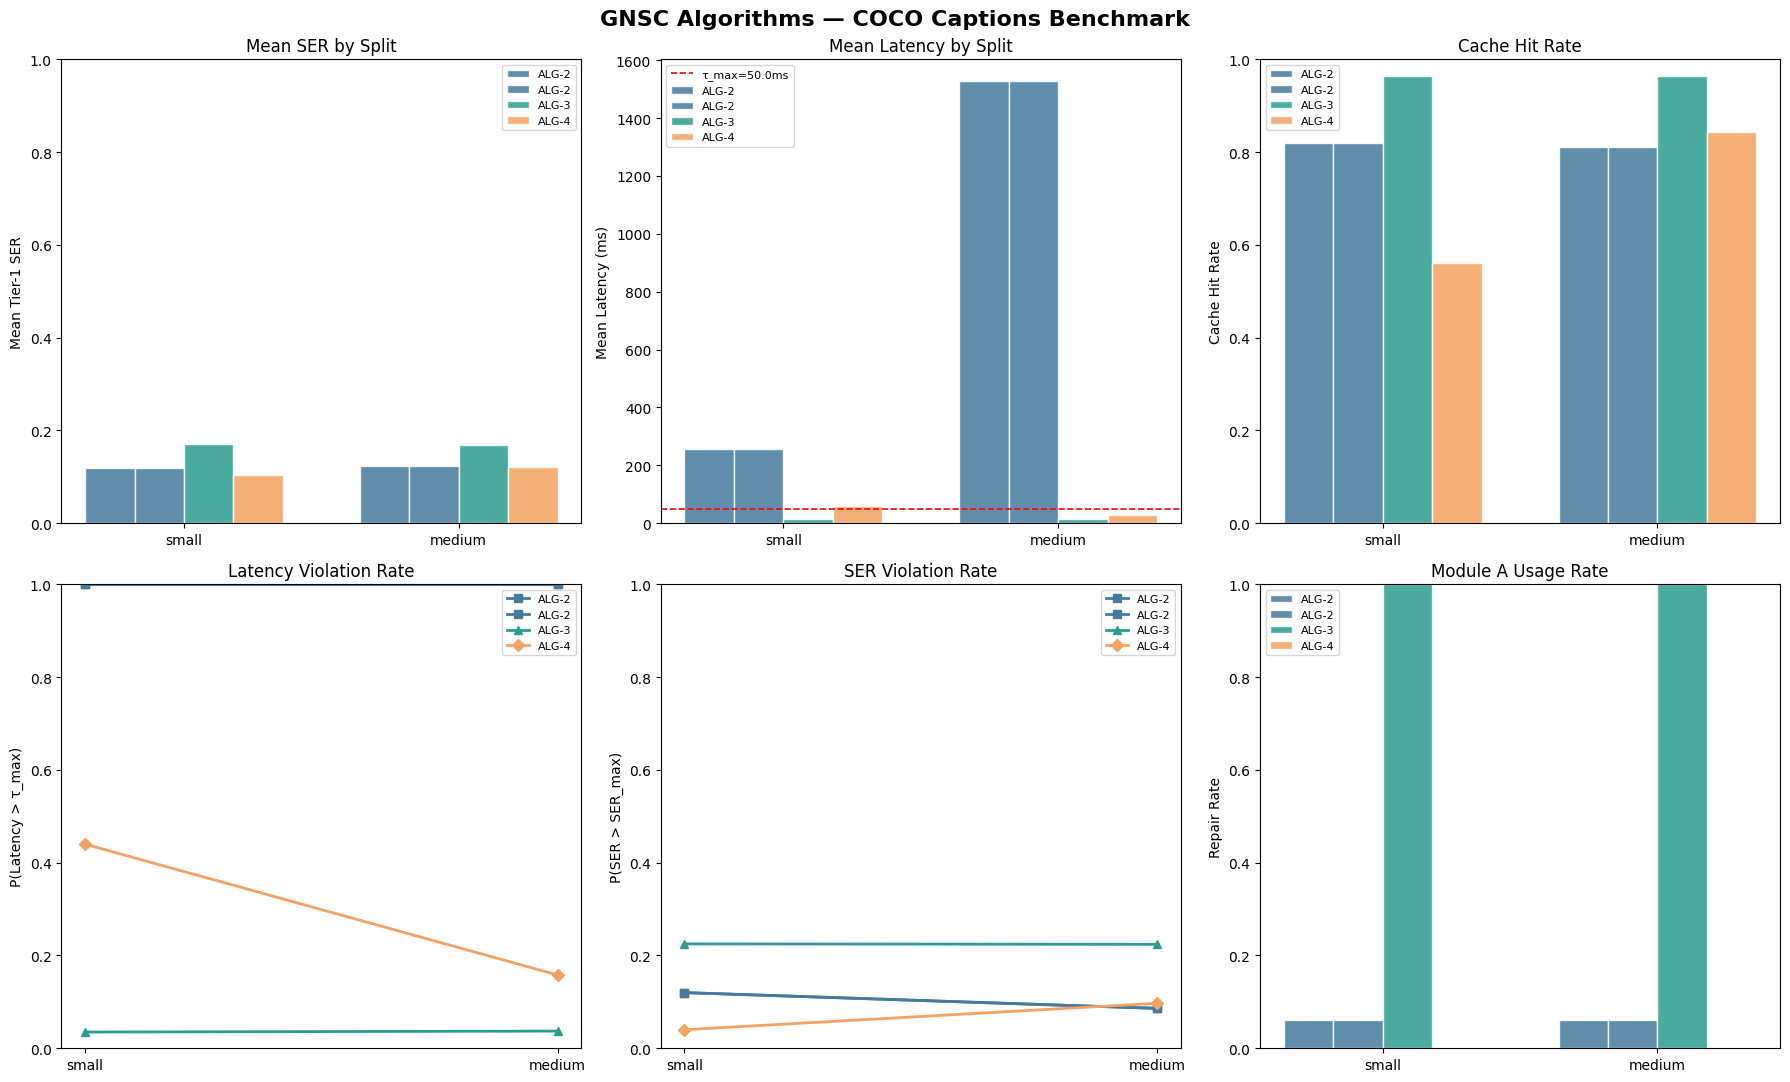

In [48]:
# @title
ALGS   = ["ALG-2", "ALG-2", "ALG-3", "ALG-4"]
SPLITS = ["small", "medium"]
COLORS = {"ALG-1": "#e63946", "ALG-2": "#457b9d", "ALG-3": "#2a9d8f", "ALG-4": "#f4a261"}
MARKS  = {"ALG-1": "o",       "ALG-2": "s",       "ALG-3": "^",       "ALG-4": "D"}

def get(split: str, alg: str, attr: str) -> float:
    for s in ALL_STATS[split]:
        if s.algorithm == alg:
            return getattr(s, attr)
    return 0.0

fig, axes = plt.subplots(2, 3, figsize=(18, 11))
fig.suptitle("GNSC Algorithms — COCO Captions Benchmark", fontsize=16, fontweight="bold")

x = np.arange(len(SPLITS))
w = 0.18

# 1a mean SER
ax = axes[0, 0]
for i, alg in enumerate(ALGS):
    ax.bar(x + i * w, [get(sp, alg, "mean_ser") for sp in SPLITS],
           w, label=alg, color=COLORS[alg], alpha=0.85, edgecolor="white")
ax.set_xticks(x + w * 1.5); ax.set_xticklabels(SPLITS)
ax.set_ylabel("Mean Tier-1 SER"); ax.set_title("Mean SER by Split"); ax.set_ylim(0, 1); ax.legend(fontsize=8)

# 1b mean latency
ax = axes[0, 1]
for i, alg in enumerate(ALGS):
    ax.bar(x + i * w, [get(sp, alg, "mean_latency") for sp in SPLITS],
           w, label=alg, color=COLORS[alg], alpha=0.85, edgecolor="white")
ax.axhline(CFG.tau_max_ms, color="red", ls="--", lw=1.2, label=f"τ_max={CFG.tau_max_ms}ms")
ax.set_xticks(x + w * 1.5); ax.set_xticklabels(SPLITS)
ax.set_ylabel("Mean Latency (ms)"); ax.set_title("Mean Latency by Split"); ax.legend(fontsize=8)

# 1c cache hit rate
ax = axes[0, 2]
for i, alg in enumerate(ALGS):
    ax.bar(x + i * w, [get(sp, alg, "cache_hit_rate") for sp in SPLITS],
           w, label=alg, color=COLORS[alg], alpha=0.85, edgecolor="white")
ax.set_xticks(x + w * 1.5); ax.set_xticklabels(SPLITS)
ax.set_ylabel("Cache Hit Rate"); ax.set_title("Cache Hit Rate"); ax.set_ylim(0, 1); ax.legend(fontsize=8)

# 1d latency violation rate
ax = axes[1, 0]
for alg in ALGS:
    ax.plot(SPLITS, [get(sp, alg, "p_lat_violation") for sp in SPLITS],
            marker=MARKS[alg], color=COLORS[alg], label=alg, lw=2)
ax.set_ylabel("P(Latency > τ_max)"); ax.set_title("Latency Violation Rate"); ax.legend(fontsize=8); ax.set_ylim(0, 1)

# 1e SER violation rate
ax = axes[1, 1]
for alg in ALGS:
    ax.plot(SPLITS, [get(sp, alg, "p_ser_violation") for sp in SPLITS],
            marker=MARKS[alg], color=COLORS[alg], label=alg, lw=2)
ax.set_ylabel("P(SER > SER_max)"); ax.set_title("SER Violation Rate"); ax.legend(fontsize=8); ax.set_ylim(0, 1)

# 1f repair rate
ax = axes[1, 2]
for i, alg in enumerate(ALGS):
    ax.bar(x + i * w, [get(sp, alg, "repair_rate") for sp in SPLITS],
           w, label=alg, color=COLORS[alg], alpha=0.85, edgecolor="white")
ax.set_xticks(x + w * 1.5); ax.set_xticklabels(SPLITS)
ax.set_ylabel("Repair Rate"); ax.set_title("Module A Usage Rate"); ax.set_ylim(0, 1); ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig("/content/fig1_benchmark.png", dpi=150, bbox_inches="tight")
plt.show()

### — Plots: SER and latency convergence over time (Fig 2)

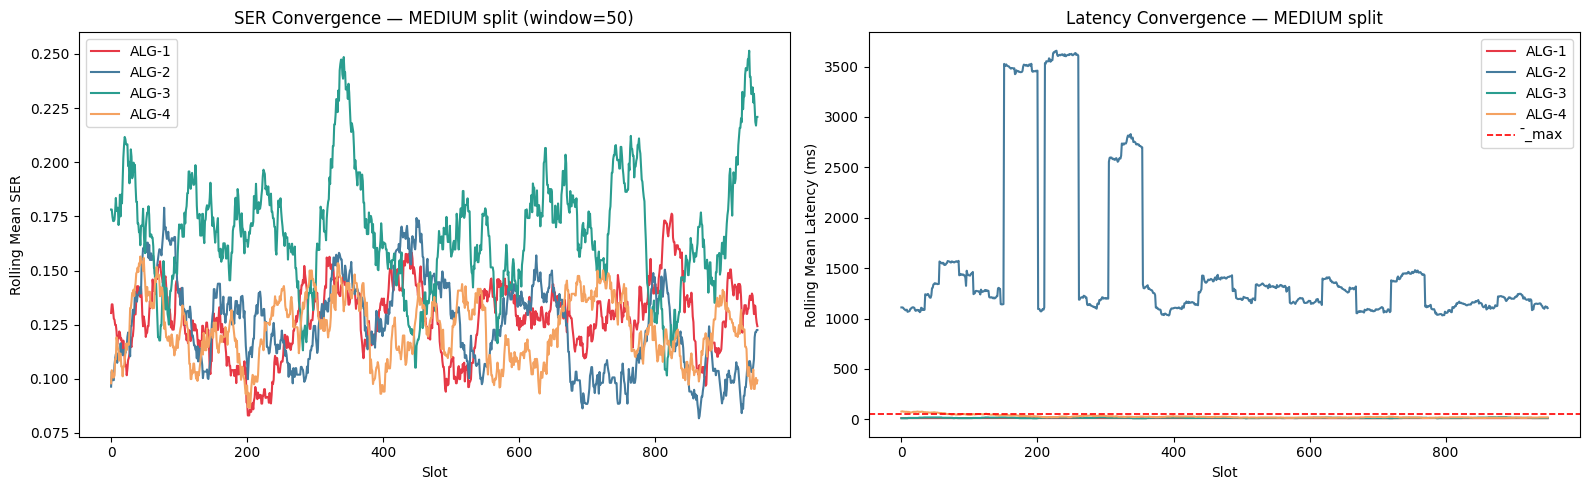

In [40]:
ALGS   = ['ALG-1', 'ALG-2', 'ALG-3', 'ALG-4']
COLORS = {'ALG-1': '#e63946', 'ALG-2': '#457b9d', 'ALG-3': '#2a9d8f', 'ALG-4': '#f4a261'}
MARKS  = {'ALG-1': 'o',       'ALG-2': 's',       'ALG-3': '^',       'ALG-4': 'D'}

WINDOW = max(1, len(DS_MEDIUM) // 20)

def rolling(arr: List[float], w: int) -> np.ndarray:
    return np.convolve(arr, np.ones(w) / w, mode='valid')

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

ax = axes[0]
for alg in ALGS:
    ax.plot(rolling([s.tier1_ser for s in RES_MEDIUM[alg]], WINDOW),
            color=COLORS[alg], label=alg, lw=1.5)
ax.set_xlabel('Slot'); ax.set_ylabel('Rolling Mean SER')
ax.set_title(f'SER Convergence — MEDIUM split (window={WINDOW})'); ax.legend()

ax = axes[1]
for alg in ALGS:
    ax.plot(rolling([s.total_latency for s in RES_MEDIUM[alg]], WINDOW),
            color=COLORS[alg], label=alg, lw=1.5)
ax.axhline(CFG.tau_max_ms, color='red', ls='--', lw=1.2, label='̄̄_max')
ax.set_xlabel('Slot'); ax.set_ylabel('Rolling Mean Latency (ms)')
ax.set_title('Latency Convergence — MEDIUM split'); ax.legend()

plt.tight_layout()
plt.savefig('/content/fig2_convergence.png', dpi=150, bbox_inches='tight')
plt.show()

### — Plots: SER vs SNR and SER vs BW scatter (Fig 3)

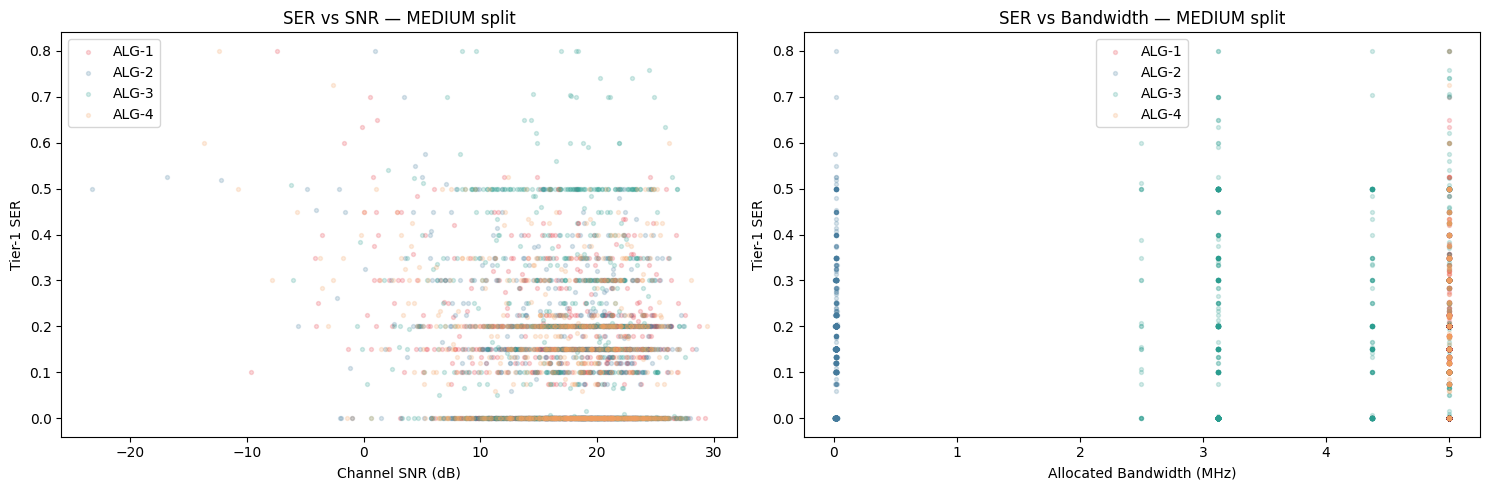

In [43]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

ax = axes[0]
for alg in ALGS:
    ax.scatter(
        [s.channel_snr_db for s in RES_MEDIUM[alg]],
        [s.tier1_ser      for s in RES_MEDIUM[alg]],
        alpha=0.2, s=8, color=COLORS[alg], label=alg,
    )
ax.set_xlabel('Channel SNR (dB)'); ax.set_ylabel('Tier-1 SER')
ax.set_title('SER vs SNR — MEDIUM split'); ax.legend()

ax = axes[1]
for alg in ALGS:
    ax.scatter(
        [s.bandwidth_mhz for s in RES_MEDIUM[alg]],
        [s.tier1_ser     for s in RES_MEDIUM[alg]],
        alpha=0.2, s=8, color=COLORS[alg], label=alg,
    )
ax.set_xlabel('Allocated Bandwidth (MHz)'); ax.set_ylabel('Tier-1 SER')
ax.set_title('SER vs Bandwidth — MEDIUM split'); ax.legend()

plt.tight_layout()
plt.savefig('/content/fig3_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

### — Plots: Latency CDF (Fig 4)

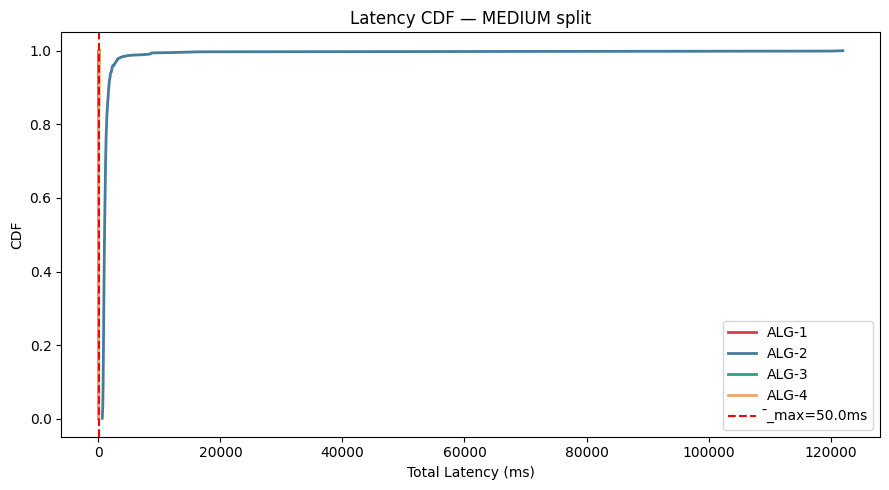

In [44]:
fig, ax = plt.subplots(figsize=(9, 5))
for alg in ALGS:
    lats = sorted(s.total_latency for s in RES_MEDIUM[alg])
    cdf  = np.arange(1, len(lats) + 1) / len(lats)
    ax.plot(lats, cdf, color=COLORS[alg], label=alg, lw=2)
ax.axvline(CFG.tau_max_ms, color='red', ls='--', lw=1.5, label=f'̄̄_max={CFG.tau_max_ms}ms')
ax.set_xlabel('Total Latency (ms)'); ax.set_ylabel('CDF')
ax.set_title('Latency CDF — MEDIUM split'); ax.legend()
plt.tight_layout()
plt.savefig('/content/fig4_cdf.png', dpi=150, bbox_inches='tight')
plt.show()

### — Plots: Model selection frequency (Fig 5)

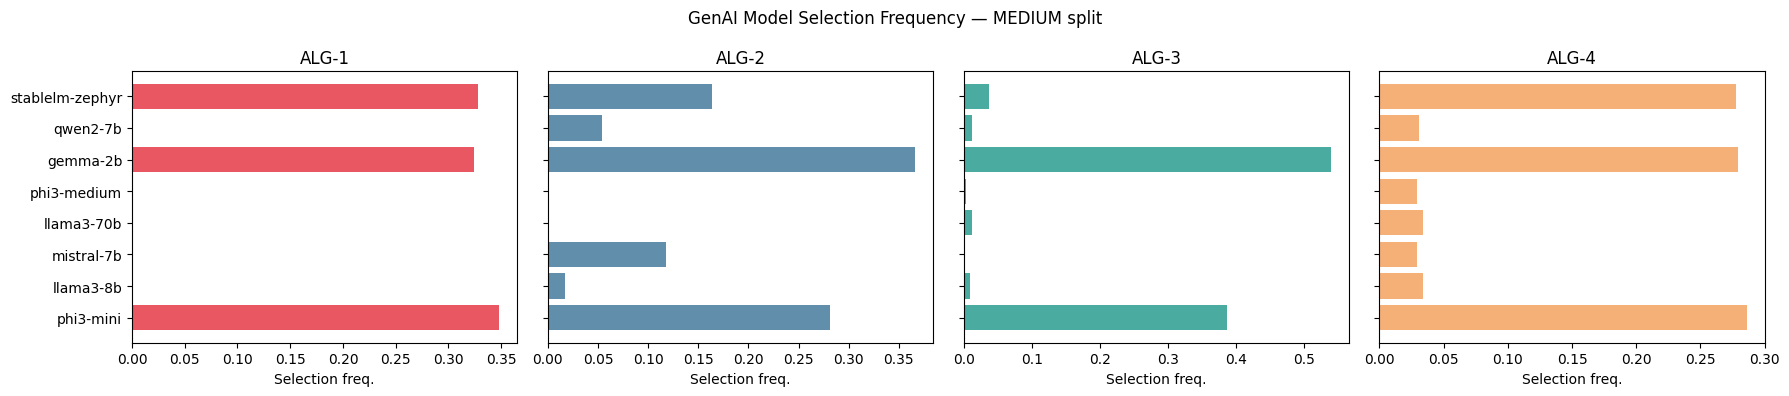

In [45]:
fig, axes = plt.subplots(1, 4, figsize=(18, 4), sharey=True)
model_names = [m.name for m in MODEL_LIBRARY]
for i, alg in enumerate(ALGS):
    freq = np.zeros(len(MODEL_LIBRARY))
    for s in RES_MEDIUM[alg]:
        freq[s.model_selected] += 1
    freq /= freq.sum()
    axes[i].barh(model_names, freq, color=COLORS[alg], alpha=0.85)
    axes[i].set_title(alg); axes[i].set_xlabel('Selection freq.')
fig.suptitle('GenAI Model Selection Frequency — MEDIUM split')
plt.tight_layout()
plt.savefig('/content/fig5_model_freq.png', dpi=150, bbox_inches='tight')
plt.show()

### — Plots: Tier-1 vs Tier-2 SER comparison (Fig 6)

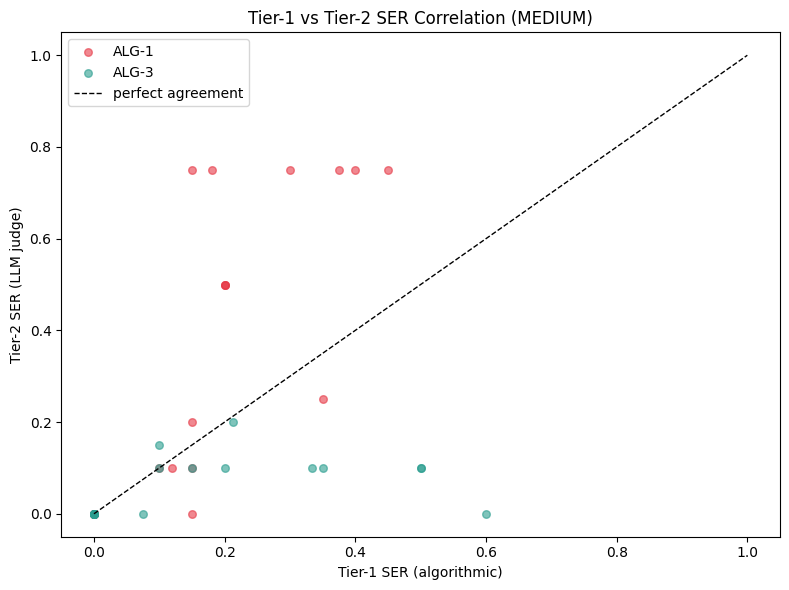

In [46]:
paired = [(s.tier1_ser, s.tier2_ser, s.algorithm)
          for alg in ALGS for s in RES_MEDIUM[alg] if s.tier2_ser is not None]

if paired:
    t1s, t2s, alg_labels = zip(*paired)
    fig, ax = plt.subplots(figsize=(8, 6))
    for alg in ALGS:
        pts = [(t1, t2) for t1, t2, a in paired if a == alg]
        if pts:
            ax.scatter(*zip(*pts), alpha=0.6, s=30, color=COLORS[alg], label=alg)
    ax.plot([0, 1], [0, 1], 'k--', lw=1, label='perfect agreement')
    ax.set_xlabel('Tier-1 SER (algorithmic)'); ax.set_ylabel('Tier-2 SER (LLM judge)')
    ax.set_title('Tier-1 vs Tier-2 SER Correlation (MEDIUM)'); ax.legend()
    plt.tight_layout()
    plt.savefig('/content/fig6_tier_correlation.png', dpi=150, bbox_inches='tight')
    plt.show()

### — Plots: Multi-metric radar chart (Fig 7)

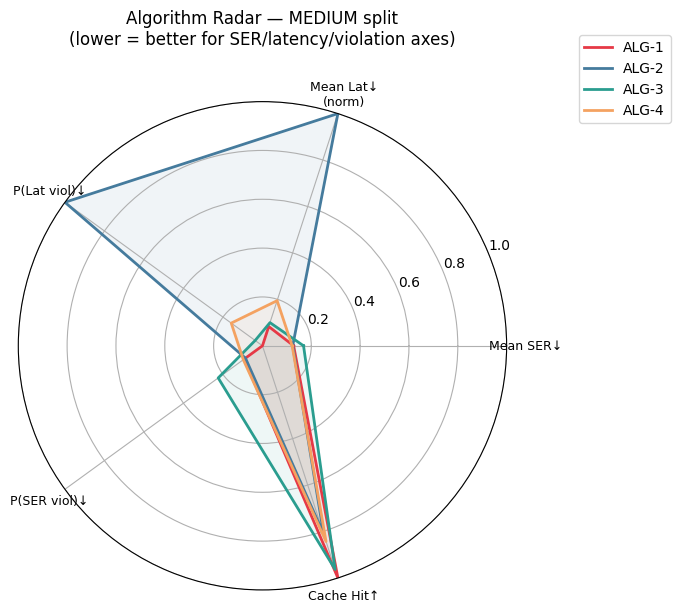

In [47]:
metrics = [
    ('mean_ser',        'Mean SER↓'),
    ('mean_latency',    'Mean Lat↓\n(norm)'),
    ('p_lat_violation', 'P(Lat viol)↓'),
    ('p_ser_violation', 'P(SER viol)↓'),
    ('cache_hit_rate',  'Cache Hit↑'),
]
norms = np.array([1.0, CFG.tau_max_ms * 3, 1.0, 1.0, 1.0])

raw = {
    alg: np.clip(
        np.array([get('medium', alg, m) for m, _ in metrics]) / norms,
        0.0, 1.0
    )
    for alg in ALGS
}

angles = np.linspace(0, 2 * np.pi, len(metrics), endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))
for alg in ALGS:
    vals = raw[alg].tolist() + [raw[alg][0]]
    ax.plot(angles, vals, color=COLORS[alg], lw=2, label=alg)
    ax.fill(angles, vals, color=COLORS[alg], alpha=0.08)
ax.set_xticks(angles[:-1])
ax.set_xticklabels([lab for _, lab in metrics], fontsize=9)
ax.set_ylim(0, 1)
ax.set_title('Algorithm Radar — MEDIUM split\n(lower = better for SER/latency/violation axes)', y=1.1)
ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.15))
plt.tight_layout()
plt.savefig('/content/fig7_radar.png', dpi=150, bbox_inches='tight')
plt.show()